# Experiment (DBSCAN)

---

Name : Shruti Hore

PRN : 24070126172

---

## DBSCAN Algorithm

### Input:
- Dataset D
- eps (ε): radius for neighborhood
- min_samples: minimum number of points to form a dense region

### Output:
- Cluster labels for each point (Noise labeled as -1)

---

### Steps:

1. Mark all points in dataset D as **unvisited**.

2. For each unvisited point P:
   - Mark P as **visited**.
   - Find all neighbors of P within distance ε (eps).

3. If the number of neighbors < min_samples:
   - Mark P as **Noise**.

4. Else:
   - Create a new cluster C.
   - Add P to cluster C.

5. For each neighbor point N of P:
   - If N is not visited:
     - Mark N as visited.
     - Find its neighbors within ε.
     - If neighbors ≥ min_samples:
       - Add them to the current neighborhood list.

   - If N is not yet part of any cluster:
     - Add N to cluster C.

6. Repeat steps until all reachable points are added to cluster C.

7. Move to the next unvisited point and repeat the process.

---

### Key Concepts:

- **Core Point:** Has ≥ min_samples neighbors within ε  
- **Border Point:** Has fewer neighbors but lies within ε of a core point  
- **Noise Point:** Not part of any cluster  

---

### Output Interpretation:

- Each cluster is assigned a unique label  
- Noise points are labeled as **-1**

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

In [2]:
data = load_breast_cancer()
X = data.data
y_true = data.target  
print("Dataset shape:", X.shape)

Dataset shape: (569, 30)


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Standardizes features so that all variables contribute equally to distance calculations.

In [4]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

In [5]:
kmeans = KMeans(n_clusters=2, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)

In [6]:
agg = AgglomerativeClustering(n_clusters=2)
agg_labels = agg.fit_predict(X_scaled)


- **Silhouette Score:**
Measures how well each point fits within its cluster compared to other clusters (higher is better).

- **Davies-Bouldin Index:**
Evaluates cluster separation and compactness (lower values indicate better clustering).

- **Adjusted Rand Index (ARI):**
Measures similarity between predicted clusters and true labels, adjusted for chance (range: -1 to 1).

- **Normalized Mutual Information (NMI):**
Quantifies shared information between predicted and true labels (range: 0 to 1).

- **Homogeneity:**
Checks whether each cluster contains only data points from a single class.

- **Completeness:**
Checks whether all data points of a class are assigned to the same cluster.

- **V-measure:**
Harmonic mean of homogeneity and completeness, balancing both metrics.


In [ ]:
def evaluate_clustering(name, X, labels, y_true):
    print(f"\n===== {name} Evaluation =====")
    
    if len(set(labels)) > 1:
        print("Silhouette Score:", silhouette_score(X, labels))
        print("Davies-Bouldin Index:", davies_bouldin_score(X, labels))
    else:
        print("Silhouette Score: Not valid (only one cluster)")
        print("Davies-Bouldin Index: Not valid")
    
    print("Adjusted Rand Index:", adjusted_rand_score(y_true, labels))
    print("Normalized Mutual Info:", normalized_mutual_info_score(y_true, labels))
    print("Homogeneity:", homogeneity_score(y_true, labels))
    print("Completeness:", completeness_score(y_true, labels))
    print("V-measure:", v_measure_score(y_true, labels))

In [8]:
evaluate_clustering("DBSCAN", X_scaled, db_labels, y_true)
evaluate_clustering("K-Means", X_scaled, km_labels, y_true)
evaluate_clustering("Hierarchical", X_scaled, agg_labels, y_true)



===== DBSCAN Evaluation =====
Silhouette Score: -0.016791147519226224
Davies-Bouldin Index: 2.246278815714925
Adjusted Rand Index: 0.20778783944349796
Normalized Mutual Info: 0.14526332853197083
Homogeneity: 0.15142046250606445
Completeness: 0.1395873581194716
V-measure: 0.14526332853197083

===== K-Means Evaluation =====
Silhouette Score: 0.3447344346611054
Davies-Bouldin Index: 1.3092887340398864
Adjusted Rand Index: 0.676504895633523
Normalized Mutual Info: 0.562020936206382
Homogeneity: 0.5510191905176488
Completeness: 0.5734709578141939
V-measure: 0.5620209362063822

===== Hierarchical Evaluation =====
Silhouette Score: 0.33938477753669855
Davies-Bouldin Index: 1.369963541894103
Adjusted Rand Index: 0.5750409366326297
Normalized Mutual Info: 0.45691492004987283
Homogeneity: 0.44621386691302517
Completeness: 0.46814184767130673
V-measure: 0.4569149200498728


In [9]:
def get_metrics(X, labels, y_true):
    if len(set(labels)) > 1:
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X, labels)
    else:
        sil = None
        dbi = None

    return [
        sil,
        dbi,
        adjusted_rand_score(y_true, labels),
        normalized_mutual_info_score(y_true, labels),
        homogeneity_score(y_true, labels),
        completeness_score(y_true, labels),
        v_measure_score(y_true, labels)
    ]

results = pd.DataFrame({
    "Metric": [
        "Silhouette",
        "Davies-Bouldin",
        "ARI",
        "NMI",
        "Homogeneity",
        "Completeness",
        "V-measure"
    ],
    "DBSCAN": get_metrics(X_scaled, db_labels, y_true),
    "KMeans": get_metrics(X_scaled, km_labels, y_true),
    "Hierarchical": get_metrics(X_scaled, agg_labels, y_true)
})

print("\n=== COMPARISON TABLE ===")
print(results)


=== COMPARISON TABLE ===
           Metric    DBSCAN    KMeans  Hierarchical
0      Silhouette -0.016791  0.344734      0.339385
1  Davies-Bouldin  2.246279  1.309289      1.369964
2             ARI  0.207788  0.676505      0.575041
3             NMI  0.145263  0.562021      0.456915
4     Homogeneity  0.151420  0.551019      0.446214
5    Completeness  0.139587  0.573471      0.468142
6       V-measure  0.145263  0.562021      0.456915


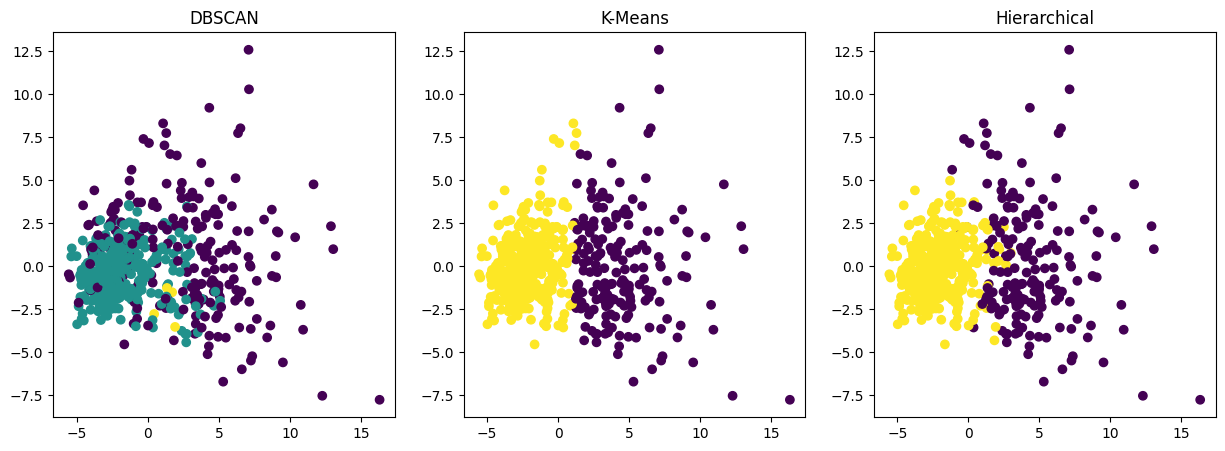

In [10]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.scatter(X_pca[:,0], X_pca[:,1], c=db_labels, cmap='viridis')
plt.title("DBSCAN")

plt.subplot(1,3,2)
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_labels, cmap='viridis')
plt.title("K-Means")

plt.subplot(1,3,3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=agg_labels, cmap='viridis')
plt.title("Hierarchical")

plt.show()

# Conclusion
The results show that DBSCAN is not suitable for this high-dimensional dataset, as it failed to form well-defined clusters and produced poor metric scores. K-Means performed the best, indicating that the data is more suited to centroid-based clustering, while Hierarchical clustering provided reasonable but slightly inferior results compared to K-Means.